In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torchvision.datasets import CIFAR10
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional

from src.utils import *
from src.analysis import *
from src.model import FineTunedModel



In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FineTunedModel(num_classes=10).to(device)
model.load_state_dict(torch.load('weights/finetune_weights.pth', map_location=device))
target_layer = model.feature_extractor[5]
D = torch.load('weights/hals_nnd_D.pth')


Loading subset from: data/subset
  cassette_player:  10 images (label=0)
  chain_saw   :  10 images (label=1)
  church      :  10 images (label=2)
  English_springer:  10 images (label=3)
  French_horn :  10 images (label=4)
  garbage_truck:  10 images (label=5)
  gas_pump    :  10 images (label=6)
  golf_ball   :  10 images (label=7)
  parachute   :  10 images (label=8)
  tench       :  10 images (label=9)

Total: 100 images loaded
Using device: cuda

Loading model and dictionary...

Analyzing 100 images in batches of 10...


/home/tamnt/.conda/envs/xfrt128/lib/python3.10/site-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Processed batch 1/10 (10/100 images)
Processed batch 2/10 (20/100 images)
Processed batch 3/10 (30/100 images)
Processed batch 4/10 (40/100 images)
Processed batch 5/10 (50/100 images)
Processed batch 6/10 (60/100 images)
Processed batch 7/10 (70/100 images)
Processed batch 8/10 (80/100 images)
Processed batch 9/10 (90/100 images)
Processed batch 10/10 (100/100 images)

Computing similarity matrices (vectorized)...

Extracting intra/inter-class similarities...

INTRA-CLASS SIMILARITY (same class)
weight    : mean=0.6083, std=0.1560
sparse    : mean=0.1436, std=0.0256
topk      : mean=0.1212, std=0.1284

INTER-CLASS SIMILARITY (different classes)
weight    : mean=0.3323, std=0.1077
sparse    : mean=0.1334, std=0.0189
topk      : mean=0.0262, std=0.0589

DIFFERENCE (Intra - Inter)
weight    : +0.2759
sparse    : +0.0101
topk      : +0.0950

Saved visualization to: similarity_analysis.png


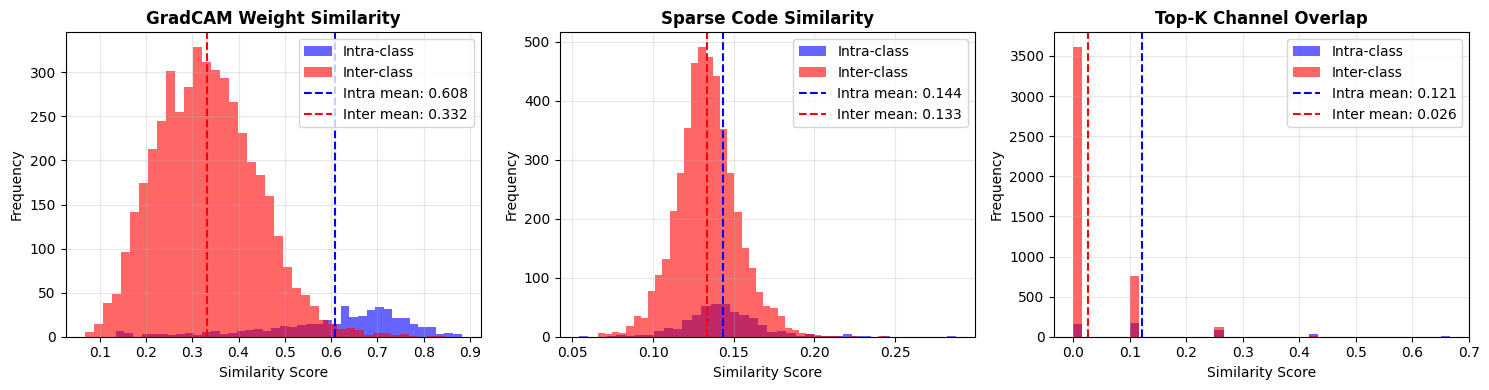

In [3]:
subset_paths = load_subset(subset_root="data/subset")
analysis_result = run_complete_analysis(
    model=model,
    target_layer=target_layer,
    D=torch.load('weights/hals_nnd_D.pth'),
    subset_paths=subset_paths,
    k=5,
    lam=1e-2,
    batch_size=10
)

In [4]:
# ===== Analyze a single test image =====
print("\n" + "="*70)
print("Analyzing Test Image")
print("="*70)

# Option 1: Load image from path
image_path = "data/subset/church/1.jpeg"  # Change this to your image path
test_image = load_image(image_path)

# Option 2: Or use from dataloader (for testing with CIFAR-10)
# test_image, test_label = next(iter(data_loader))

# Create analyzer
analyzer = TopKActivationAnalyzer(model, target_layer, D, device)

# Get model prediction
with torch.no_grad():
    logits = model(test_image.to(device))
    pred_class = logits.argmax(dim=1).item()
    confidence = torch.softmax(logits, dim=1)[0, pred_class].item()

# class_names = get_cifar10_class_names()
print(f"Image path: {image_path}")
# print(f"Predicted class: {pred_class} ({class_names[pred_class]})")
print(f"Confidence: {confidence:.4f}")

# Analyze top-5 most influential activation maps
results = analyzer.visualize_analysis(
    image=test_image,
    k=5,
    class_idx=None,  # Use predicted class
    lam=1e-2
)

# Access results
print(f"Number of top maps analyzed: {len(results['top_maps'])}")
print(f"Top channel indices: {results['top_indices']}")


Analyzing Test Image
Image path: data/subset/church/1.jpeg
Confidence: 1.0000



Top-5 Most Influential Activation Maps Analysis

Rank 1: Channel 133
  GradCAM Weight: 0.003079
  Sparse Code Stats:
    - Non-zero atoms: 23/500
    - L1 norm: 128.924126
    - Max coefficient: 33.415009
    - Top 5 atom indices: [458, 488, 255, 3, 99]
    - Top 5 coefficients: [33.41500879 13.54396237 10.99850564  9.87031173  9.30938522]

Rank 2: Channel 171
  GradCAM Weight: 0.002987
  Sparse Code Stats:
    - Non-zero atoms: 40/500
    - L1 norm: 107.072483
    - Max coefficient: 12.631390
    - Top 5 atom indices: [46, 410, 42, 458, 317]
    - Top 5 coefficients: [12.6313901   9.11219571  7.58708116  7.220824    6.5919924 ]

Rank 3: Channel 70
  GradCAM Weight: 0.002941
  Sparse Code Stats:
    - Non-zero atoms: 35/500
    - L1 norm: 48.954595
    - Max coefficient: 4.991638
    - Top 5 atom indices: [163, 408, 117, 9, 72]
    - Top 5 coefficients: [4.99163824 3.8602451  3.56657815 3.41254555 3.36344515]

Rank 4: Channel 40
  GradCAM Weight: 0.002903
  Sparse Code Stats:
    - No

In [5]:
# ===== Analyze a single test image =====
print("\n" + "="*70)
print("Analyzing Test Image")
print("="*70)

# Option 1: Load image from path
image_path = "data/subset/church/2.jpeg"  # Change this to your image path
test_image = load_image(image_path)

# Option 2: Or use from dataloader (for testing with CIFAR-10)
# test_image, test_label = next(iter(data_loader))

# Create analyzer
analyzer = TopKActivationAnalyzer(model, target_layer, D, device)

# Get model prediction
with torch.no_grad():
    logits = model(test_image.to(device))
    pred_class = logits.argmax(dim=1).item()
    confidence = torch.softmax(logits, dim=1)[0, pred_class].item()

# class_names = get_cifar10_class_names()
print(f"Image path: {image_path}")
# print(f"Predicted class: {pred_class} ({class_names[pred_class]})")
print(f"Confidence: {confidence:.4f}")

# Analyze top-5 most influential activation maps
results = analyzer.visualize_analysis(
    image=test_image,
    k=5,
    class_idx=None,  # Use predicted class
    lam=1e-2
)

# Access results
print(f"Number of top maps analyzed: {len(results['top_maps'])}")
print(f"Top channel indices: {results['top_indices']}")


Analyzing Test Image
Image path: data/subset/church/2.jpeg
Confidence: 1.0000

Top-5 Most Influential Activation Maps Analysis

Rank 1: Channel 107
  GradCAM Weight: 0.002622
  Sparse Code Stats:
    - Non-zero atoms: 37/500
    - L1 norm: 117.536747
    - Max coefficient: 15.284773
    - Top 5 atom indices: [398, 358, 69, 367, 488]
    - Top 5 coefficients: [15.28477259 10.72983397  9.80085233  7.77807726  6.3592573 ]

Rank 2: Channel 158
  GradCAM Weight: 0.001978
  Sparse Code Stats:
    - Non-zero atoms: 52/500
    - L1 norm: 150.654694
    - Max coefficient: 16.621200
    - Top 5 atom indices: [220, 107, 163, 150, 267]
    - Top 5 coefficients: [16.62119967 12.92509668  8.99095405  6.27805355  5.99289525]

Rank 3: Channel 49
  GradCAM Weight: 0.001864
  Sparse Code Stats:
    - Non-zero atoms: 34/500
    - L1 norm: 181.055358
    - Max coefficient: 24.991443
    - Top 5 atom indices: [481, 121, 101, 148, 275]
    - Top 5 coefficients: [24.99144323 14.64298001 14.14822719 13.39991

In [6]:
# ===== Analyze a single test image =====
print("\n" + "="*70)
print("Analyzing Test Image")
print("="*70)

# Option 1: Load image from path
image_path = "data/subset/tench/2.jpeg"  # Change this to your image path
test_image = load_image(image_path)

# Option 2: Or use from dataloader (for testing with CIFAR-10)
# test_image, test_label = next(iter(data_loader))

# Create analyzer
analyzer = TopKActivationAnalyzer(model, target_layer, D, device)

# Get model prediction
with torch.no_grad():
    logits = model(test_image.to(device))
    pred_class = logits.argmax(dim=1).item()
    confidence = torch.softmax(logits, dim=1)[0, pred_class].item()

# class_names = get_cifar10_class_names()
print(f"Image path: {image_path}")
# print(f"Predicted class: {pred_class} ({class_names[pred_class]})")
print(f"Confidence: {confidence:.4f}")

# Analyze top-5 most influential activation maps
results = analyzer.visualize_analysis(
    image=test_image,
    k=5,
    class_idx=None,  # Use predicted class
    lam=1e-2
)

# Access results
print(f"Number of top maps analyzed: {len(results['top_maps'])}")
print(f"Top channel indices: {results['top_indices']}")


Analyzing Test Image
Image path: data/subset/tench/2.jpeg
Confidence: 1.0000

Top-5 Most Influential Activation Maps Analysis

Rank 1: Channel 70
  GradCAM Weight: 0.003473
  Sparse Code Stats:
    - Non-zero atoms: 47/500
    - L1 norm: 75.920263
    - Max coefficient: 8.724077
    - Top 5 atom indices: [480, 266, 487, 276, 290]
    - Top 5 coefficients: [8.72407666 5.99399445 5.08009459 4.06625707 3.52971572]

Rank 2: Channel 180
  GradCAM Weight: 0.002834
  Sparse Code Stats:
    - Non-zero atoms: 38/500
    - L1 norm: 185.273780
    - Max coefficient: 20.331029
    - Top 5 atom indices: [121, 46, 461, 287, 469]
    - Top 5 coefficients: [20.33102936 12.22601373 10.6719187  10.18448475  9.91432887]

Rank 3: Channel 136
  GradCAM Weight: 0.002716
  Sparse Code Stats:
    - Non-zero atoms: 51/500
    - L1 norm: 98.496717
    - Max coefficient: 8.989265
    - Top 5 atom indices: [136, 400, 181, 283, 275]
    - Top 5 coefficients: [8.98926519 6.43497246 4.28336776 4.27162288 4.12753213

In [13]:
def visualize_atom_overlap_matrix(overlap_matrix: np.ndarray, class_names: List[str]):
    """Visualize the atom overlap matrix as a heatmap."""
    plt.figure(figsize=(5, 4))
    
    # Mask diagonal
    mask = np.eye(10, dtype=bool)
    overlap_masked = np.ma.masked_where(mask, overlap_matrix)
    
    plt.imshow(overlap_masked, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(label='Jaccard Similarity')
    
    # Set ticks
    plt.xticks(range(10), class_names, rotation=45, ha='right', fontsize=6)
    plt.yticks(range(10), class_names, fontsize=6)
    
    # Add values
    for i in range(10):
        for j in range(10):
            if i != j and overlap_matrix[i, j] > 0:
                plt.text(j, i, f'{overlap_matrix[i, j]:.2f}', 
                        ha='center', va='center', fontsize=4)
    
    plt.title('Top-5 Characteristic Atoms Overlap Between Classes', 
              fontsize=7, fontweight='bold')
    plt.xlabel('Class')
    plt.ylabel('Class')
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/atom_overlap_matrix.png', dpi=150, bbox_inches='tight')
    print("\nSaved atom overlap visualization to: figures/atom_overlap_matrix.png")
    plt.show()




In [14]:
def analyze_class_characteristic_atoms(results: List[dict], n_atoms: int, 
                                       top_k_atoms: int = 10, threshold: float = 0.1,
                                       top_channels: int = 10):
    """
    Analyze which atoms are characteristic for each class.
    
    Args:
        results: List of analysis results with 'label', 'path', and 'analysis' keys
        n_atoms: Total number of atoms in dictionary
        top_k_atoms: Number of top atoms to report per class
        threshold: Minimum average weight to consider an atom as characteristic
        top_channels: Number of top influential channels to average (default: 10)
        
    Returns:
        Dictionary with class-specific atom statistics
    """
    # Extract class names from paths in results
    # Path format: 'data/subset/class_name/image.jpeg'
    class_name_set = set()
    label_to_class_name = {}
    
    for r in results:
        path = r['path']
        label = r['label']
        # Extract class name from path (second to last component)
        class_name = path.split('/')[-2]
        class_name_set.add(class_name)
        label_to_class_name[label] = class_name
    
    # Sort class names by their label indices
    sorted_labels = sorted(label_to_class_name.keys())
    class_names = [label_to_class_name[label] for label in sorted_labels]
    n_classes = len(class_names)
    
    print(f"\nDetected {n_classes} classes: {class_names}")
    
    # Aggregate sparse codes by class
    class_codes = {i: [] for i in range(n_classes)}
    
    for r in results:
        label = r['label']
        sparse_codes = r['analysis']['sparse_codes']  # (n_channels, n_atoms)
        weights = r['analysis']['weights']  # (n_channels,)
        
        # Get top-K most influential channels
        top_channel_indices = np.argsort(weights)[-top_channels:]
        
        # Average across only top-K channels for this image
        top_codes = sparse_codes[top_channel_indices]  # (top_channels, n_atoms)
        avg_code = np.mean(np.abs(top_codes), axis=0)  # (n_atoms,)
        class_codes[label].append(avg_code)
    
    # Compute statistics per class
    class_stats = {}
    
    for class_idx in range(n_classes):
        if len(class_codes[class_idx]) == 0:
            continue
        
        codes = np.array(class_codes[class_idx])  # (n_images, n_atoms)
        
        # Compute mean and std for each atom across images in this class
        mean_activation = np.mean(codes, axis=0)  # (n_atoms,)
        std_activation = np.std(codes, axis=0)
        
        # Compute consistency: how often each atom is used (non-zero)
        usage_rate = np.mean(codes > 1e-6, axis=0)  # (n_atoms,)
        
        class_stats[class_idx] = {
            'mean_activation': mean_activation,
            'std_activation': std_activation,
            'usage_rate': usage_rate,
            'n_images': len(codes)
        }
    
    # Find characteristic atoms for each class
    print("\n" + "="*80)
    print("CLASS-CHARACTERISTIC ATOMS ANALYSIS")
    print("="*80)
    
    class_characteristic_atoms = {}
    
    for class_idx in range(n_classes):
        if class_idx not in class_stats:
            continue
        
        stats = class_stats[class_idx]
        mean_act = stats['mean_activation']
        usage = stats['usage_rate']
        
        # Score: combination of activation strength and usage frequency
        # High score = strong activation AND frequently used in this class
        scores = mean_act * usage
        
        # Get top-k atoms
        top_indices = np.argsort(scores)[-top_k_atoms:][::-1]
        
        # Filter by threshold
        characteristic = []
        for atom_idx in top_indices:
            if scores[atom_idx] >= threshold:
                characteristic.append({
                    'atom_idx': int(atom_idx),
                    'score': float(scores[atom_idx]),
                    'mean_activation': float(mean_act[atom_idx]),
                    'usage_rate': float(usage[atom_idx])
                })
        
        class_characteristic_atoms[class_idx] = characteristic
        
        # Print results
        print(f"\n{class_names[class_idx].upper()} (Class {class_idx}):")
        print(f"  Images analyzed: {stats['n_images']}")
        print(f"  (Using top-{top_channels} influential channels per image)")
        print(f"  Characteristic atoms (score ≥ {threshold}):")
        
        if len(characteristic) > 0:
            for rank, atom_info in enumerate(characteristic, 1):
                print(f"    #{rank:2d}  Atom {atom_info['atom_idx']:3d}  |  "
                      f"Score: {atom_info['score']:6.3f}  |  "
                      f"Avg Activation: {atom_info['mean_activation']:6.3f}  |  "
                      f"Usage: {atom_info['usage_rate']*100:5.1f}%")
        else:
            print(f"    No atoms exceed threshold {threshold}")
    
    # Cross-class analysis: find atoms shared vs unique
    print("\n" + "="*80)
    print("CROSS-CLASS ATOM ANALYSIS")
    print("="*80)
    
    # Get top-5 atoms for each class for overlap analysis
    top_atoms_per_class = {}
    for class_idx, atoms in class_characteristic_atoms.items():
        if len(atoms) > 0:
            top_atoms_per_class[class_idx] = [a['atom_idx'] for a in atoms[:5]]
    
    # Find shared atoms (appear in multiple classes)
    atom_class_map = {}
    for class_idx, atom_list in top_atoms_per_class.items():
        for atom_idx in atom_list:
            if atom_idx not in atom_class_map:
                atom_class_map[atom_idx] = []
            atom_class_map[atom_idx].append(class_idx)
    
    shared_atoms = {atom: classes for atom, classes in atom_class_map.items() 
                    if len(classes) > 1}
    unique_atoms = {atom: classes[0] for atom, classes in atom_class_map.items() 
                    if len(classes) == 1}
    
    print(f"\nShared atoms (used by multiple classes): {len(shared_atoms)}")
    if len(shared_atoms) > 0:
        for atom_idx, class_list in sorted(shared_atoms.items(), 
                                          key=lambda x: len(x[1]), reverse=True)[:10]:
            class_names_list = [class_names[c] for c in class_list]
            print(f"  Atom {atom_idx:3d}: {', '.join(class_names_list)} ({len(class_list)} classes)")
    
    print(f"\nClass-unique atoms (top-5 only in one class): {len(unique_atoms)}")
    for class_idx in range(n_classes):
        unique_for_class = [atom for atom, cls in unique_atoms.items() if cls == class_idx]
        if len(unique_for_class) > 0:
            print(f"  {class_names[class_idx]:12s}: {unique_for_class}")
    
    # Compute inter-class atom overlap
    print("\n" + "="*80)
    print("PAIRWISE CLASS ATOM OVERLAP (Jaccard Similarity)")
    print("="*80)
    
    overlap_matrix = np.zeros((n_classes, n_classes))
    for i in range(n_classes):
        for j in range(n_classes):
            if i in top_atoms_per_class and j in top_atoms_per_class:
                atoms_i = set(top_atoms_per_class[i])
                atoms_j = set(top_atoms_per_class[j])
                overlap_matrix[i, j] = jaccard_sim(list(atoms_i), list(atoms_j))
    
    # Print matrix
    print("\n      ", end="")
    for i in range(n_classes):
        print(f"{class_names[i][:4]:>5s}", end="")
    print()
    
    for i in range(n_classes):
        print(f"{class_names[i][:4]:>5s}:", end="")
        for j in range(n_classes):
            if overlap_matrix[i, j] > 0:
                print(f"{overlap_matrix[i, j]:5.2f}", end="")
            else:
                print(f"  -  ", end="")
        print()
    
    # Visualize overlap matrix
    visualize_atom_overlap_matrix(overlap_matrix, class_names)
    
    return {
        'class_stats': class_stats,
        'characteristic_atoms': class_characteristic_atoms,
        'shared_atoms': shared_atoms,
        'unique_atoms': unique_atoms,
        'overlap_matrix': overlap_matrix,
        'class_names': class_names  # Include class names in return value
    }


Detected 10 classes: ['cassette_player', 'chain_saw', 'church', 'English_springer', 'French_horn', 'garbage_truck', 'gas_pump', 'golf_ball', 'parachute', 'tench']

CLASS-CHARACTERISTIC ATOMS ANALYSIS

CASSETTE_PLAYER (Class 0):
  Images analyzed: 10
  (Using top-10 influential channels per image)
  Characteristic atoms (score ≥ 0.1):
    # 1  Atom  89  |  Score:  1.863  |  Avg Activation:  2.070  |  Usage:  90.0%
    # 2  Atom  99  |  Score:  1.756  |  Avg Activation:  1.756  |  Usage: 100.0%
    # 3  Atom 393  |  Score:  1.663  |  Avg Activation:  1.663  |  Usage: 100.0%
    # 4  Atom 488  |  Score:  1.587  |  Avg Activation:  1.587  |  Usage: 100.0%
    # 5  Atom  13  |  Score:  1.529  |  Avg Activation:  1.529  |  Usage: 100.0%
    # 6  Atom 410  |  Score:  1.425  |  Avg Activation:  1.425  |  Usage: 100.0%
    # 7  Atom 273  |  Score:  1.425  |  Avg Activation:  1.583  |  Usage:  90.0%
    # 8  Atom 367  |  Score:  1.269  |  Avg Activation:  1.269  |  Usage: 100.0%
    # 9  Atom 4

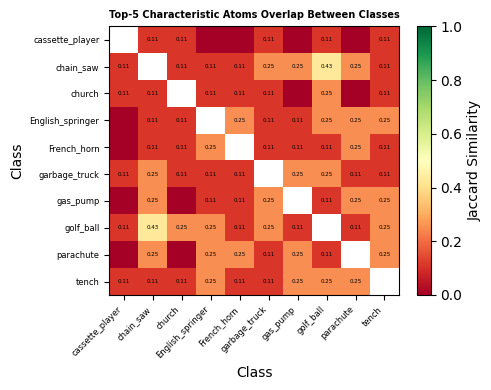

In [15]:
atom_analysis = analyze_class_characteristic_atoms(
        results=analysis_result['results'],
        n_atoms=len(D),
        top_k_atoms=10,
        threshold=0.1
    )

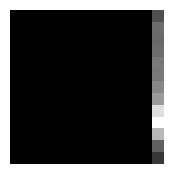

In [10]:
plt.figure(figsize=(2, 2))
plt.imshow(D[107].cpu().numpy(), cmap='gray')
plt.axis('off')
plt.show()

In [11]:
atom_analysis.keys()

dict_keys(['class_stats', 'characteristic_atoms', 'shared_atoms', 'unique_atoms', 'overlap_matrix', 'class_names'])


Visualizing 8 classes with unique atoms
Saved visualization to: figures/unique_atoms_grid.png


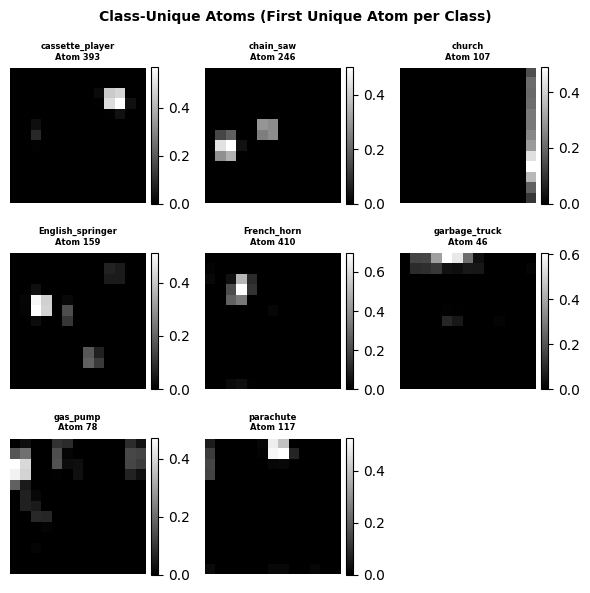

In [12]:
def visualize_unique_atoms_grid(atom_analysis: dict, D: torch.Tensor, 
                                 figsize: tuple = (6, 6), cmap: str = 'gray'):
    """
    Visualize the first unique atom for each class in a 3x3 grid.
    
    Args:
        atom_analysis: Output from analyze_class_characteristic_atoms containing 'unique_atoms'
        D: Dictionary tensor of atoms (n_atoms, H, W)
        figsize: Figure size
        cmap: Colormap for visualization
    """
    unique_atoms = atom_analysis['unique_atoms']
    class_names = atom_analysis['class_names']
    
    # Group unique atoms by class
    class_unique_atoms = {}
    for atom_idx, class_idx in unique_atoms.items():
        if class_idx not in class_unique_atoms:
            class_unique_atoms[class_idx] = []
        class_unique_atoms[class_idx].append(atom_idx)
    
    # Get classes with unique atoms (sorted by class index)
    classes_with_unique = sorted(class_unique_atoms.keys())
    n_classes_with_unique = len(classes_with_unique)
    
    print(f"\nVisualizing {n_classes_with_unique} classes with unique atoms")
    
    # Create 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    axes = axes.flatten()
    
    for idx, class_idx in enumerate(classes_with_unique):
        # if idx >= 9:  # Only show first 9
        #     break
            
        ax = axes[idx]
        
        # Get first unique atom for this class
        first_atom_idx = class_unique_atoms[class_idx][0]
        atom = D[first_atom_idx].cpu().numpy()
        
        # Display atom
        im = ax.imshow(atom, cmap=cmap)
        ax.set_title(f"{class_names[class_idx]}\nAtom {first_atom_idx}", 
                     fontsize=6, fontweight='bold')
        ax.axis('off')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Hide unused subplots
    for idx in range(n_classes_with_unique, 9):
        axes[idx].axis('off')
    
    plt.suptitle('Class-Unique Atoms (First Unique Atom per Class)', 
                 fontsize=10, fontweight='bold', y=0.98)
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/unique_atoms_grid.png', dpi=150, bbox_inches='tight')
    print("Saved visualization to: figures/unique_atoms_grid.png")
    plt.show()


# Usage example:
visualize_unique_atoms_grid(atom_analysis, D)